# Outras capacidades do modelo YOLO

## Segmentação


0: 384x640 15 persons, 2 backpacks, 4 handbags, 3.5ms
Speed: 0.7ms preprocess, 3.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

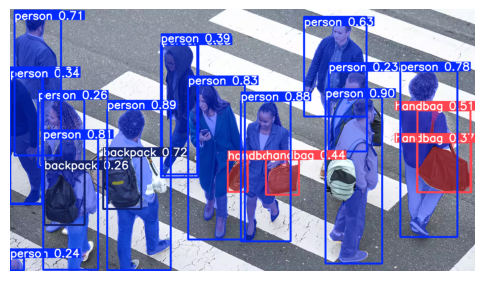

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")

img = Image.open("../data/pedestrians.png")

result = model(
    img, 
    conf=0.2, 
    # Retorna máscaras com a mesma resolução da imagem de entrada
    retina_masks=True  
    )[0]

img_res = result.plot(
    conf=True,  
    boxes=True, 
    labels=True,  
    masks=True,  
)

img_res = img_res[:, :, ::-1]  # Converte BGR para RGB

plt.figure(figsize=(6, 8))
plt.imshow(img_res)
plt.axis("off")


In [3]:
masks = result.masks.data
# masks.shape[0] indica o número de máscaras detectadas
print(masks.shape)

torch.Size([21, 720, 1280])


## Detecção de pose de pessoas

A detecção de pose envolve a identificação de pontos chave (keypoints) de pessoas presentes na imagem. O modelo YOLO pré-treinado é capaz de identificar os seguintes 17 keypoints:

| Índice | Nome do Ponto |
| :---: | :--- |
| 0 | Nariz |
| 1 | Olho esquerdo |
| 2 | Olho direito |
| 3 | Orelha esquerda |
| 4 | Orelha direita |
| 5 | Ombro esquerdo |
| 6 | Ombro direito |
| 7 | Cotovelo esquerdo |
| 8 | Cotovelo direito |
| 9 | Punho esquerdo |
| 10 | Punho direito |
| 11 | Quadril esquerdo |
| 12 | Quadril direito |
| 13 | Joelho esquerdo |
| 14 | Joelho direito |
| 15 | Tornozelo esquerdo |
| 16 | Tornozelo direito |

A saída crua do modelo é um tensor possuindo $n*(1+4+3∗17)$ valores, onde $n$ é o número de pontos âncora. Para cada âncora, o modelo retorna a probabilidade da âncora conter uma pessoa, 4 valores com as coordenadas da caixa delimitadora e 3 valores para cada ponto âncora: 2 valores são a coordenada do ponto e o terceiro valor possui a probabilidade do ponto estar visível na imagem.


0: 512x640 1 person, 3.4ms
Speed: 0.5ms preprocess, 3.4ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)


(np.float64(-0.5), np.float64(639.5), np.float64(492.5), np.float64(-0.5))

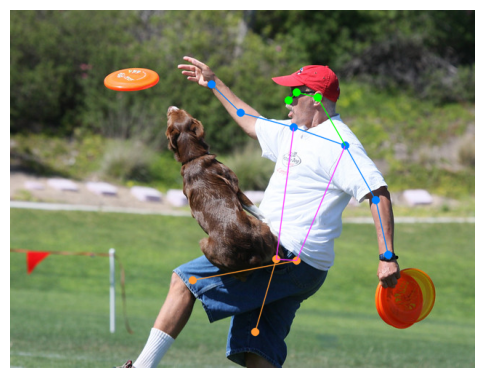

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

model = YOLO("yolo26n-pose.pt")

img = Image.open("../data/man_with_dog.jpg")

result = model(img)[0]

img_res = result.plot(
    boxes=False, 
)

img_res = img_res[:, :, ::-1]  # Converte BGR para RGB

plt.figure(figsize=(6, 8))
plt.imshow(img_res)
plt.axis("off")


In [59]:
# Nomes dos keypoints (joints) para o modelo de pose
kpt_names = model.model.kpt_names[0]

# Coordenadas
coords = result.keypoints.xy
# Probabilidade de cada keypoint estar presente
confs = result.keypoints.conf
for obj_idx in range(coords.shape[0]):
    print(f"Objeto {obj_idx}:")
    for kpt_idx in range(coords.shape[1]):
        x, y = coords[obj_idx, kpt_idx]
        conf = confs[obj_idx, kpt_idx]
        print(f"  {kpt_names[kpt_idx]}: ({x:.2f}, {y:.2f}), conf={conf:.2f}")


Objeto 0:
  nose: (383.65, 125.08), conf=0.97
  left_eye: (394.28, 114.83), conf=0.95
  right_eye: (382.23, 115.63), conf=0.11
  left_ear: (423.98, 121.45), conf=0.98
  right_ear: (395.15, 122.04), conf=0.01
  left_shoulder: (461.03, 187.11), conf=1.00
  right_shoulder: (390.01, 162.53), conf=1.00
  left_elbow: (503.18, 262.49), conf=0.99
  right_elbow: (317.85, 142.36), conf=0.98
  left_wrist: (520.52, 337.00), conf=0.99
  right_wrist: (277.73, 103.79), conf=0.96
  left_hip: (394.64, 345.30), conf=0.99
  right_hip: (366.95, 343.27), conf=1.00
  left_knee: (251.73, 372.83), conf=0.99
  right_knee: (337.49, 443.40), conf=0.97
  left_ankle: (188.10, 489.90), conf=0.20
  right_ankle: (337.65, 489.77), conf=0.02
